# Import Libraries

In [1]:
import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

2026-04-10 07:02:57.820770: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775804578.071760      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775804578.134109      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775804578.683615      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775804578.683674      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775804578.683677      24 computation_placer.cc:177] computation placer alr

# Load Dataset

In [2]:
dataset_path = "/kaggle/input/datasets/mdshadmanshakibdip18/capstone/Augmented Dataset"

filepaths = []
labels = []

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    for img in os.listdir(class_path):
        if img.lower().endswith((".png",".jpg",".jpeg")):
            filepaths.append(os.path.join(class_path, img))
            labels.append(class_name)

df = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

print("Total images:", len(df))
df.head()

Total images: 6120


,filepath,label
0,/kaggle/input/datasets/mdshadmanshakibdip18/ca...,Healthy
1,/kaggle/input/datasets/mdshadmanshakibdip18/ca...,Healthy
2,/kaggle/input/datasets/mdshadmanshakibdip18/ca...,Healthy
3,/kaggle/input/datasets/mdshadmanshakibdip18/ca...,Healthy
4,/kaggle/input/datasets/mdshadmanshakibdip18/ca...,Healthy


# Validation Split
# train (80%)
# test (20%)

In [3]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df["label"],
    random_state=42
)

print(len(train_df), len(val_df), len(test_df))
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\nTrain class distribution:")
print(train_df["label"].value_counts())

print("\nValidation class distribution:")
print(val_df["label"].value_counts())

print("\nTest class distribution:")
print(test_df["label"].value_counts())

train_df.to_csv("/kaggle/working/train_split.csv", index=False)
val_df.to_csv("/kaggle/working/val_split.csv", index=False)
test_df.to_csv("/kaggle/working/test_split.csv", index=False)

print("\nTrain/Val/Test CSVs saved successfully!")

4406 490 1224
Train size: 4406
Validation size: 490
Test size: 1224

Train class distribution:
label
Diabetic Retinopathy    2479
Healthy                 1927
Name: count, dtype: int64

Validation class distribution:
label
Diabetic Retinopathy    276
Healthy                 214
Name: count, dtype: int64

Test class distribution:
label
Diabetic Retinopathy    689
Healthy                 535
Name: count, dtype: int64

Train/Val/Test CSVs saved successfully!


# Data Leakage Check (Short)

In [4]:
print("Leakage Check:",
      len(set(train_df.filepath) & set(test_df.filepath)))

Leakage Check: 0


# Data Generators

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_generator = train_gen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label",
    target_size=(224,224), class_mode="binary", batch_size=BATCH_SIZE
)

val_generator = val_gen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=(224,224), class_mode="binary", batch_size=BATCH_SIZE
)

test_generator = test_gen.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label",
    target_size=(224,224), class_mode="binary", shuffle=False
)

Found 4406 validated image filenames belonging to 2 classes.
Found 490 validated image filenames belonging to 2 classes.
Found 1224 validated image filenames belonging to 2 classes.


# Load ResNet-50

In [6]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

I0000 00:00:1775804618.717057      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Add Custom Layers

In [7]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile Model

In [8]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

# Early Stopping

In [9]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train Model

In [10]:
start = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=[early_stop]
)

training_time = time.time() - start
print("Training Time:", training_time)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1775804633.118538      66 service.cc:152] XLA service 0x7e6538002430 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775804633.118595      66 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775804635.311491      66 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/138 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.5469 - loss: 0.7306  

I0000 00:00:1775804640.019511      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


138/138 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.5244 - loss: 0.7485 - val_accuracy: 0.5633 - val_loss: 0.6766
Epoch 2/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 120s 872ms/step - accuracy: 0.5520 - loss: 0.6977 - val_accuracy: 0.5633 - val_loss: 0.6708
Epoch 3/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 117s 850ms/step - accuracy: 0.5562 - loss: 0.6902 - val_accuracy: 0.5633 - val_loss: 0.6662
Epoch 4/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 119s 863ms/step - accuracy: 0.5819 - loss: 0.6773 - val_accuracy: 0.5633 - val_loss: 0.6626
Epoch 5/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 119s 863ms/step - accuracy: 0.5837 - loss: 0.6758 - val_accuracy: 0.5673 - val_loss: 0.6586
Epoch 6/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 118s 852ms/step - accuracy: 0.5745 - loss: 0.6749 - val_accuracy: 0.5633 - val_loss: 0.6557
Epoch 7/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 115s 830ms/step - accuracy: 0.5944 - loss: 0.6657 - val_accuracy: 0.7367 - val_loss: 0.6573
Epoch 8/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 116s 838ms/step - accuracy: 0.6069 - loss: 

# Predictions

In [11]:
start_inf = time.time()

y_prob = model.predict(test_generator)
y_pred = (y_prob > 0.5).astype(int).flatten()
y_true = test_generator.classes

inference_time = (time.time() - start_inf) / len(y_true)

39/39 ━━━━━━━━━━━━━━━━━━━━ 36s 828ms/step


# Confusion Matrix

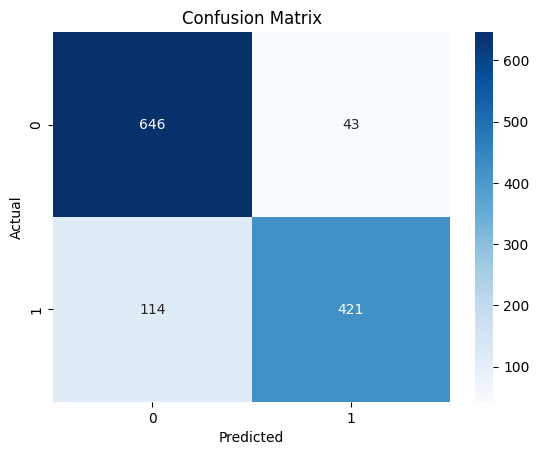

In [12]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve

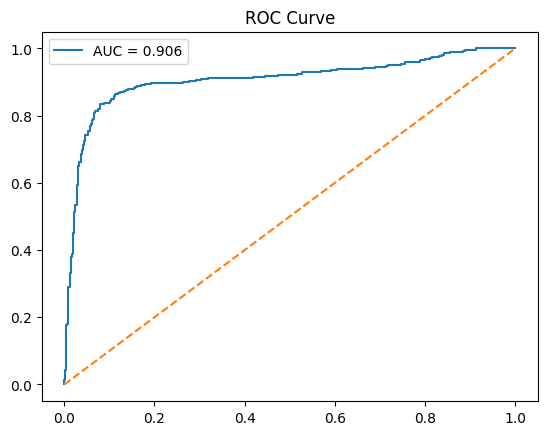

In [13]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

# Metrics (Full Table)

In [14]:
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

results = pd.DataFrame({
"Metric":[
"Accuracy","Precision","Recall (Sensitivity)","F1 Score",
"Balanced Accuracy","Specificity","False Negative Rate (FNR)",
"False Positive Rate (FPR)","AUC-ROC","Training Time","Inference Time"
],
"Value":[
accuracy_score(y_true,y_pred),
precision_score(y_true,y_pred),
recall_score(y_true,y_pred),
f1_score(y_true,y_pred),
balanced_accuracy_score(y_true,y_pred),
tn/(tn+fp),
fn/(fn+tp),
fp/(fp+tn),
roc_auc,
training_time,
inference_time
]
})

print(results)

                       Metric         Value
0                    Accuracy      0.871732
1                   Precision      0.907328
2        Recall (Sensitivity)      0.786916
3                    F1 Score      0.842843
4           Balanced Accuracy      0.862253
5                 Specificity      0.937591
6   False Negative Rate (FNR)      0.213084
7   False Positive Rate (FPR)      0.062409
8                     AUC-ROC      0.905723
9               Training Time  10430.339809
10             Inference Time      0.030399
